# Visualisierung eines Noise2Void-Runs

In diesem Notebook gibst du **einmalig** den Pfad zu deinem gespeicherten Run-Ordner an.  
Dann werden daraus automatisch geladen:
- die `config.py` (aus `used_source`),  
- dein U-Net-Modell mit dem Checkpoint `best.pt`,  
- Trainings- und Validierungs-Datasets,  
- und es werden exemplarisch je drei Beispiele aus Training und Validation geplottet.

# Parameter setzen:

In [ ]:
import os
import sys

# — Stelle hier deinen Run-Ordner ein (z.B. …/trained_models/First_Test) —
run_dir = "../trained_models/"    #_3Layers_ynetRank3"  # <-- anpassen

# GPU wählen
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # or whichever GPU you want

# Andere parameter automatisch laden

In [2]:
# ── Zelle 2: Run-Config & used_source in sys.path einfügen ──

import os
import sys
import importlib.util

# 1) Absoluter Pfad zum Run-Verzeichnis (aus Zelle 1)
run_dir = os.path.abspath(run_dir)

# 2) Pfad zum used_source-Snapshot
USED_SRC = os.path.join(run_dir, "used_source")

# 3) Ganz vorne in sys.path einfügen, damit alle Imports daraus gezogen werden
if USED_SRC not in sys.path:
    sys.path.insert(0, USED_SRC)

# (Optional) Projekt-Root als Fallback auf Position 1
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(1, PROJECT_ROOT)

# Debug: sys.path prüfen
print("⤷ sys.path[0:2] =", sys.path[:2])

# 4) Pfad zur Config im used_source-Ordner
config_path = os.path.join(USED_SRC, "config.py")

# 5) Dynamisch als Modul importieren
spec = importlib.util.spec_from_file_location("run_config", config_path)
run_config = importlib.util.module_from_spec(spec)
spec.loader.exec_module(run_config)

# 6) Absoluten Pfad für checkpoint_dir anpassen (falls relativ)
if not os.path.isabs(run_config.checkpoint_dir):
    run_config.checkpoint_dir = os.path.join(PROJECT_ROOT, run_config.checkpoint_dir)

# 7) Werte ausgeben
print(f"RUN_NAME           = {run_config.RUN_NAME}")
print(f"Checkpoint-Ordner  = {run_config.checkpoint_dir}")


⤷ sys.path[0:2] = ['/workspace/Deuterium_Denosing/trained_models/fT_ynet_5Layer/used_source', '/workspace/Deuterium_Denosing']
RUN_NAME           = fT_ynet_5Layer
Checkpoint-Ordner  = /workspace/Deuterium_Denosing/trained_models/fT_ynet_5Layer/checkpoints


# Bibliotheken und Geräte

# Model laden

In [3]:
# --- Cell A: Device & Model --------------------------------------------------
import torch, importlib, os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Verwendetes Device:", device)

# --- Modellwahl abhängig von TRAIN_METHOD und UNET_DIM ----------------------
if run_config.TRAIN_METHOD == "ynet":
    assert run_config.UNET_DIM == "2d", "Y-Net ist nur für 2-D vorhanden"
    from models.ynet2d import YNet2D as NetClass
    ckpt_name = "best_ynet.pt"
    model = NetClass(
        in_ch_noisy  = run_config.in_channels_noisy,
        in_ch_lr     = run_config.in_channels_lr,
        out_channels = run_config.out_channels,
        features     = run_config.features
    ).to(device)

else:                                    # klassischer Noise2Void-U-Net
    if run_config.UNET_DIM == "2d":
        from models.unet2d import UNet2D as NetClass
        ckpt_name = "best.pt"
    else:                                # "3d"
        from models.unet3d import UNet3D as NetClass
        ckpt_name = "best3d.pt"
    model = NetClass(
        in_channels  = run_config.in_channels,
        out_channels = run_config.out_channels,
        features     = run_config.features
    ).to(device)

# --- Checkpoint laden --------------------------------------------------------
ckpt_path = os.path.join(run_config.checkpoint_dir, ckpt_name)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state"]); model.eval()

print(f"✓ Modell geladen: {run_config.TRAIN_METHOD.upper()}-{run_config.UNET_DIM}  "
      f"({ckpt_name},  Epoch {ckpt.get('epoch','?')})")




Verwendetes Device: cuda
✓ Modell geladen: YNET-2d  (best_ynet.pt,  Epoch 991)


# Datasets & DataLoader

In [ ]:
# ── Cell B + C: End-to-End-Inference & Post-Processing ──────────────────────
import numpy as np, torch, os
from itertools import product
from math import prod
from data.data_utils import load_and_preprocess_data, low_rank

# ---------------------------------------------------------------------------#
# 1) Validation-Daten laden
# ---------------------------------------------------------------------------#
data_val = load_and_preprocess_data(
    folder_names = run_config.val_data,
    base_path    = os.path.join(PROJECT_ROOT, "datasets"),
    fourier_axes = run_config.fourier_transform_axes,
    normalize    = True,
)

if run_config.TRAIN_METHOD == "ynet":
    lowrank_val = low_rank(data_val.copy(), rank=run_config.lowrank_rank)

# ---------------------------------------------------------------------------#
# 2) Achsen-Definition
# ---------------------------------------------------------------------------#
spatial_axes = (run_config.image_axes if run_config.UNET_DIM == "2d"
                else run_config.volume_axes)            # (len==2) oder (len==3)
all_axes     = list(range(data_val.ndim))
other_axes   = [ax for ax in all_axes if ax not in spatial_axes]
ranges       = [range(data_val.shape[ax]) for ax in other_axes]

print(f"Spatial axes: {spatial_axes} | Other axes: {other_axes} "
      f"→ geplante Vorwärtspässe: {prod(len(r) for r in ranges)}")

# ---------------------------------------------------------------------------#
# 3) Output-Array anlegen
# ---------------------------------------------------------------------------#
out_data = np.zeros_like(data_val, dtype=np.complex64)

# ---------------------------------------------------------------------------#
# 4) Hilfs-Funktion
# ---------------------------------------------------------------------------#
def to_tensor(arr):          # arr shape (2,*spatial)
    return torch.from_numpy(arr)[None].to(device)

# ---------------------------------------------------------------------------#
# 5) Inference-Loop
# ---------------------------------------------------------------------------#
model.eval()
with torch.no_grad():
    for idx in product(*ranges):
        # --- Slicer für Nicht-Volumen-Achsen
        slicer = [slice(None) if ax in spatial_axes
                  else idx[other_axes.index(ax)]
                  for ax in all_axes]

        spec = data_val[tuple(slicer)]                       # komplex-Block

        if run_config.UNET_DIM == "2d":                      # -------------- 2-D
            img = np.stack([spec.real, spec.imag], axis=0).astype(np.float32)

            if run_config.TRAIN_METHOD == "ynet":
                spec_lr = lowrank_val[tuple(slicer)]
                img_lr  = np.stack([spec_lr.real, spec_lr.imag], axis=0
                                   ).astype(np.float32)
                pred = model(to_tensor(img), to_tensor(img_lr)
                             ).squeeze(0).cpu().numpy()
            else:
                pred = model(to_tensor(img)).squeeze(0).cpu().numpy()

        else:                                                # -------------- 3-D
            # Hier KEIN Transpose mehr – Dataset liefert schon (2, D1, D2, D3)
            img  = np.stack([spec.real, spec.imag], axis=0).astype(np.float32)
            pred = model(to_tensor(img)).squeeze(0).cpu().numpy()

        den = pred[0] + 1j * pred[1]
        out_data[tuple(slicer)] = den

print("✓ Inference für gesamtes Volume abgeschlossen")

# ---------------------------------------------------------------------------#
# 6) Post-Processing
# ---------------------------------------------------------------------------#
# Runs-Achse (letzte) ggf. entfernen
tgt_data = data_val[..., 0] if out_data.shape[-1] == 1 else data_val
out_data = out_data[..., 0] if out_data.shape[-1] == 1 else out_data

# Inverse FFT aus Frequenz-/Zeit-Domäne zurück in FID
axes = tuple(run_config.fourier_transform_axes)
out_data = np.fft.ifftn(np.fft.ifftshift(out_data, axes=axes), axes=axes)
tgt_data = np.fft.ifftn(np.fft.ifftshift(tgt_data, axes=axes), axes=axes)

# Low-Rank-Baseline (rein qualitativ)
rank_post = 8
baseline_data = low_rank(tgt_data, rank=rank_post)
#out_data = low_rank(out_data, rank=rank_post) 

# Gemeinsame Normierung (optional fürs Plotten)
# max_val = max(np.abs(out_data).max(),
#               np.abs(tgt_data).max(),
#               np.abs(baseline_data).max())
# out_data      /= max_val
# tgt_data      /= max_val
# baseline_data /= max_val

# FFT zurück in Spektralraum für Peaks
out_data_ft      = np.fft.fftshift(np.fft.fft(out_data, axis=axes[0]), axes=axes[0])
tgt_data_ft      = np.fft.fftshift(np.fft.fft(tgt_data, axis=axes[0]), axes=axes[0])
baseline_data_ft = np.fft.fftshift(np.fft.fft(baseline_data, axis=axes[0]), axes=axes[0])

print("✓ Post-Processing fertig:")
print("  out_data      :", out_data.shape)
print("  tgt_data      :", tgt_data.shape)
print("  baseline_data :", baseline_data.shape)




Spatial axes: (3, 4) | Other axes: [0, 1, 2, 5] → geplante Vorwärtspässe: 10164
✓ Inference für gesamtes Volume abgeschlossen
✓ Post-Processing fertig:
  out_data      : (22, 22, 21, 96, 8)
  tgt_data      : (22, 22, 21, 96, 8)
  baseline_data : (22, 22, 21, 96, 8)


# check if model uses both paths

In [5]:
# # ── Cell 6: Gate-Statistiken auf Validation ────────────────────────────────
# import torch
# import numpy as np
# from itertools import islice, product

# # 1) Ein kleines Subset an Slices auswählen (z.B. 100 zufällige Voxels)
# all_indices = list(product(*ranges))           # aus Cell 5
# np.random.seed(0)
# subset = np.random.choice(len(all_indices), size=min(100, len(all_indices)), replace=False)

# gate_sums, gate_sqs, counts = None, None, 0

# model.eval()
# with torch.no_grad():
#     for idx in islice(subset, None):
#         # a) Slicer bauen
#         slicer = [
#             slice(None) if ax in image_axes 
#             else all_indices[idx][other_axes.index(ax)] 
#             for ax in all_axes
#         ]

#         # b) Noisy- und LR-Input vorbereiten
#         spec_n   = data_val[tuple(slicer)]
#         img_noisy = np.stack([spec_n.real.astype(np.float32),
#                               spec_n.imag.astype(np.float32)], axis=0)[None]
#         if run_config.TRAIN_METHOD == "ynet":
#             spec_lr = lowrank_val[tuple(slicer)]
#             img_lr   = np.stack([spec_lr.real.astype(np.float32),
#                                  spec_lr.imag.astype(np.float32)], axis=0)[None]

#         inp_noisy = torch.from_numpy(img_noisy).to(device)
#         if run_config.TRAIN_METHOD == "ynet":
#             inp_lr = torch.from_numpy(img_lr).to(device)
#             _, gates = model.forward_with_gates(inp_noisy, inp_lr)
#         else:
#             continue  # keine Gates bei U-Net

#         # c) Gates aufsammeln
#         for i, g in enumerate(gates):
#             g = g.cpu().numpy()
#             if gate_sums is None:
#                 L = len(gates)
#                 gate_sums = [0.0] * L
#                 gate_sqs  = [0.0] * L
#             gate_sums[i] += g.mean()
#             gate_sqs[i]  += g.std()**2
#         counts += 1

# # 2) Durchschnitt und Std berechnen und ausgeben
# print(f"Gate-Statistiken über {counts} Beispiele:")
# for i in range(len(gate_sums)):
#     mean_all = gate_sums[i] / counts
#     std_all  = np.sqrt(gate_sqs[i] / counts)
#     print(f" Ebene {i:2d}: Mean = {mean_all:.3f},  Std = {std_all:.3f}")



# Optional als matlab datei speichern

In [6]:
from scipy.io import savemat
savemat('P08.mat', {'Data': out_data})

# Compare FID

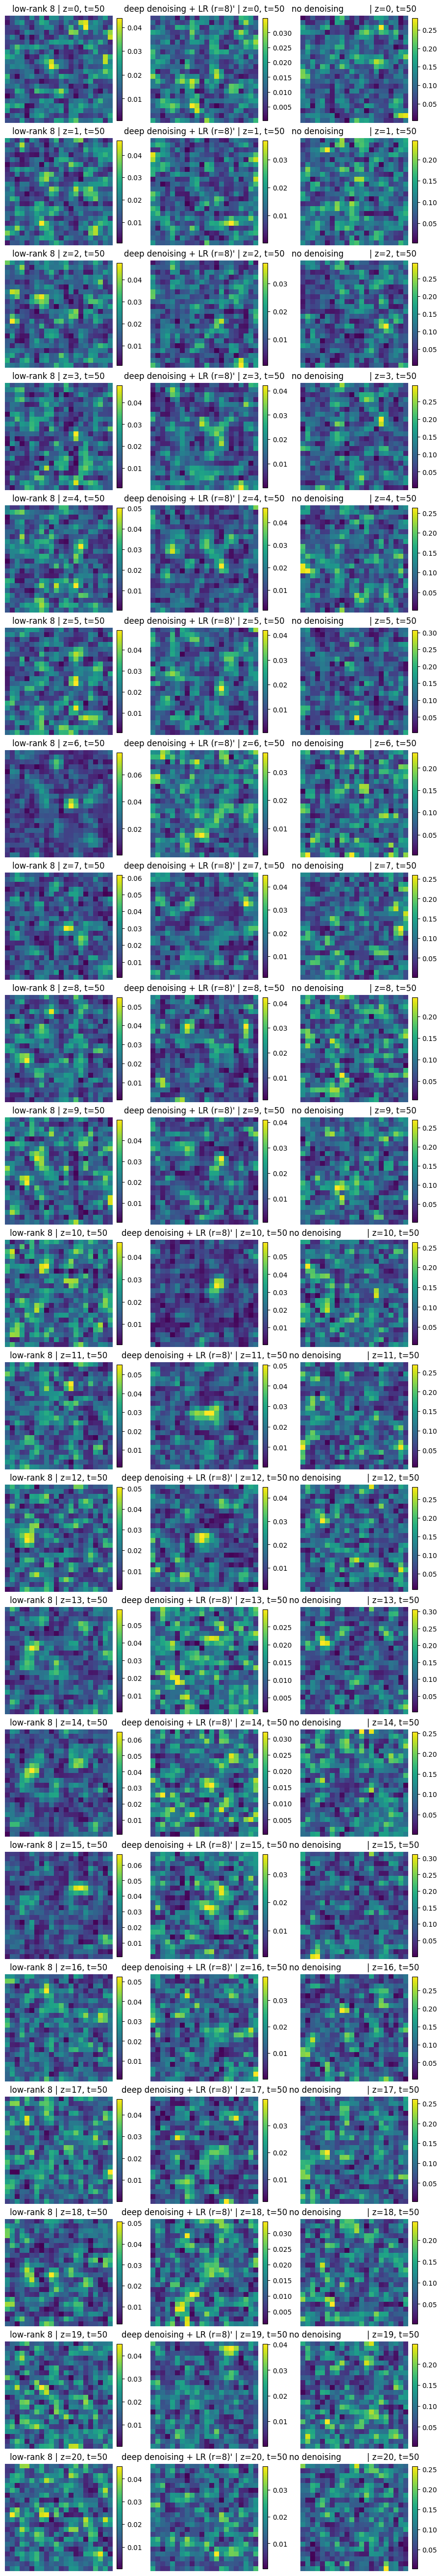

In [18]:
# ── Vergleich aller Z-Slices: Low-Rank | Deep Denoising | Input ─────────────

import numpy as np
import matplotlib.pyplot as plt

# 1) t- und T-Indizes einstellen
t, T = 15, 7

# 2) Anzahl der Z-Slices automatisch ermitteln
n_slices = out_data.shape[2]

# 3) Subplots erzeugen: n_slices Zeilen × 3 Spalten
fig, axes = plt.subplots(
    n_slices, 3,
    figsize=(9, n_slices * 2.5),
    constrained_layout=True
)

for i, z in enumerate(range(n_slices)):
    # 4) 2D-Slices extrahieren
    slice_lr   = np.abs(baseline_data[:, :, z, t, T])  # Low-Rank
    slice_deep = np.abs(out_data[:, :, z, t, T])       # Deep Denoised
    slice_in   = np.abs(tgt_data[:, :, z, t, T])       # Original Input

    # 5a) Low-Rank
    im0 = axes[i, 0].imshow(slice_lr,   cmap='viridis')
    axes[i, 0].set_title(f"low-rank {rank_post} | z={z}, t={t}")
    axes[i, 0].axis('off')
    plt.colorbar(im0, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # 5b) Deep Denoising
    im1 = axes[i, 1].imshow(slice_deep, cmap='viridis')
    axes[i, 1].set_title(f"deep denoising + LR (r={rank_post})' | z={z}, t={t}")
    axes[i, 1].axis('off')
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # 5c) Input
    im2 = axes[i, 2].imshow(slice_in,   cmap='viridis')
    axes[i, 2].set_title(f"no denoising          | z={z}, t={t}")
    axes[i, 2].axis('off')
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.savefig("denoising_p2n.png", dpi=300)
plt.show()

# Compare spectra

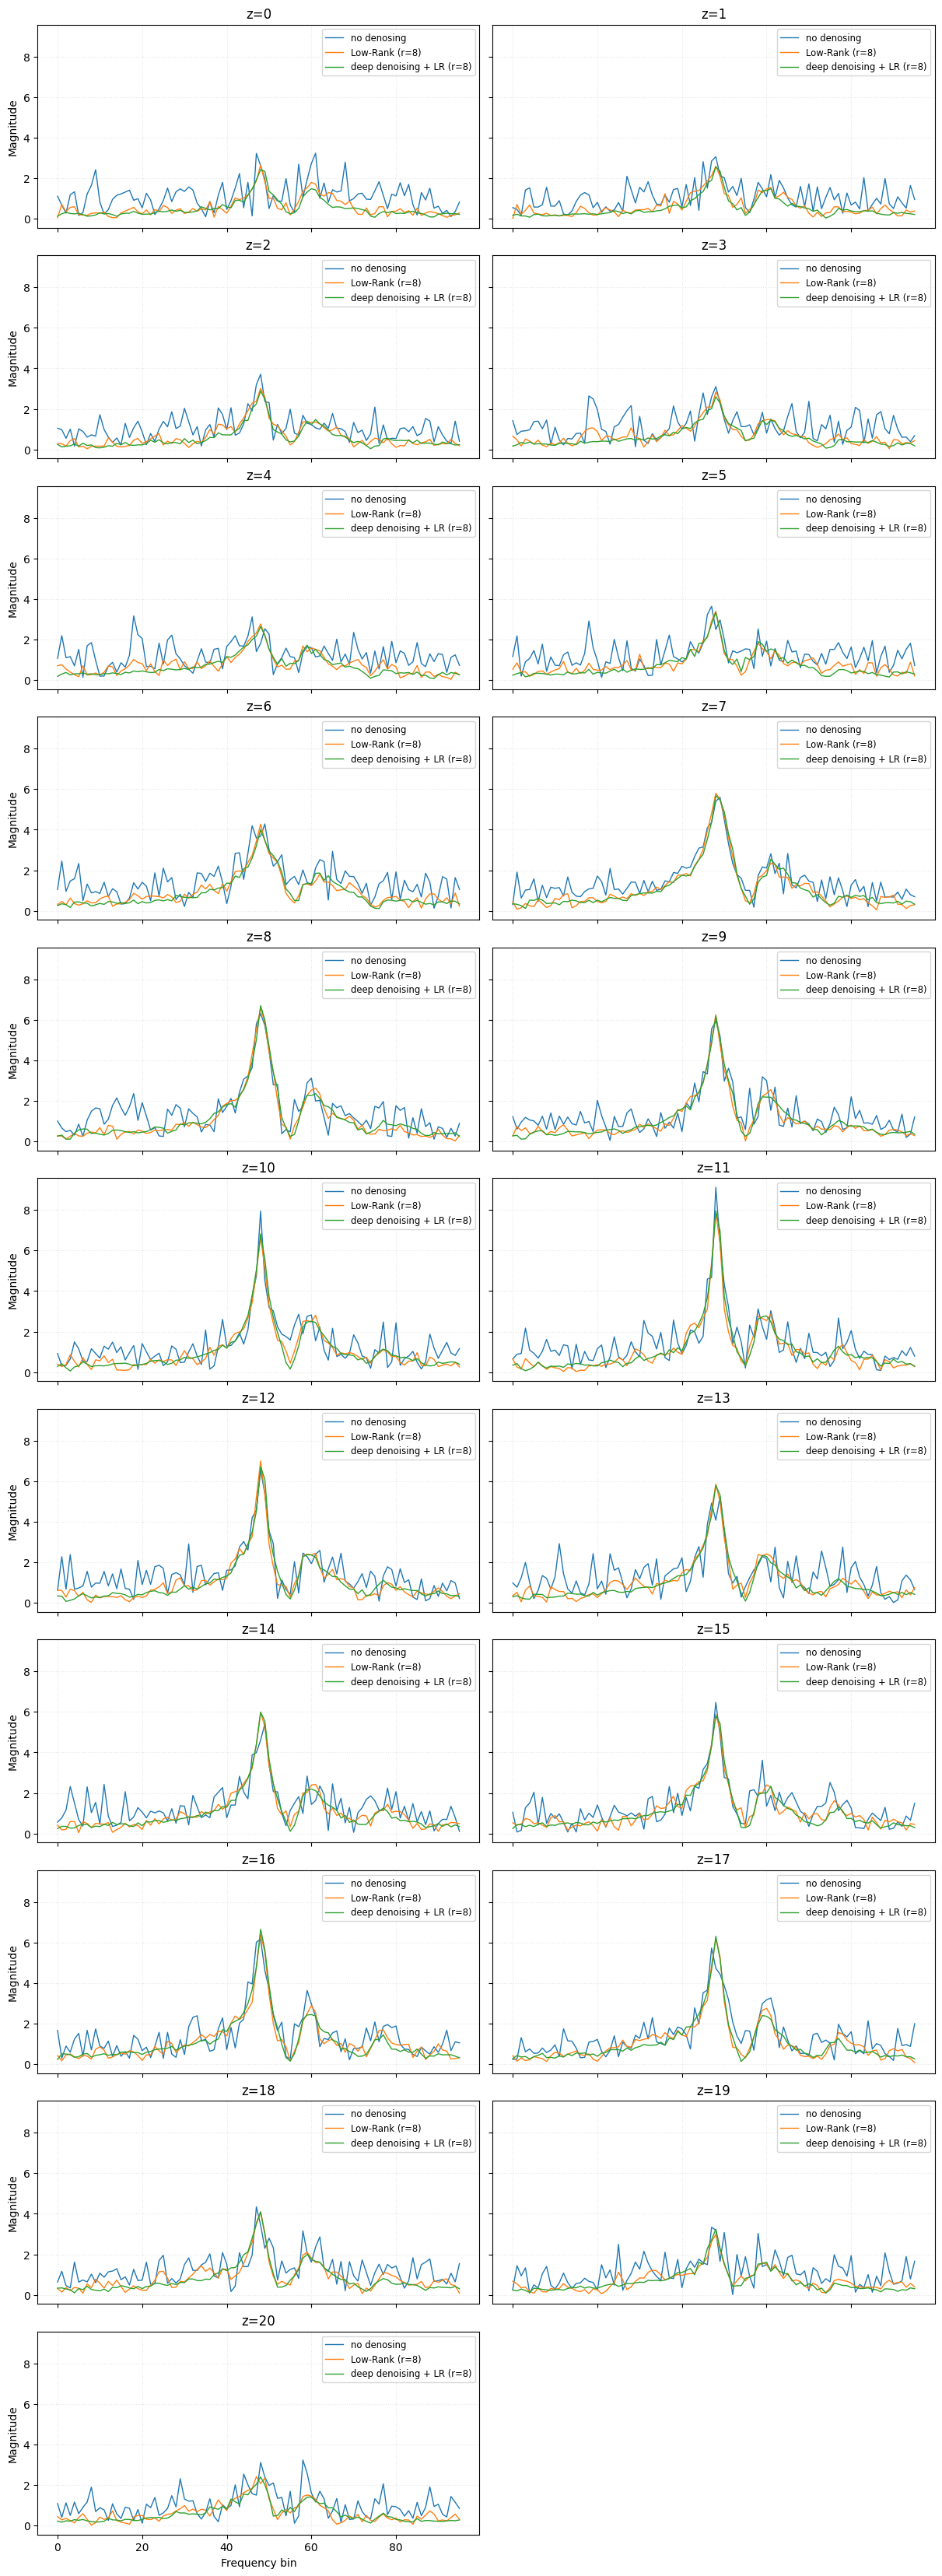

In [8]:
x,y,T = 10, 10, 0

# 2a) Deep-Denoising Spektrum
spec_deep = np.fft.fft(out_data, axis=3)
spec_deep = np.fft.fftshift(spec_deep, axes=3)

# 2b) Noisy Input Spektrum
spec_noisy = np.fft.fft(tgt_data, axis=3)
spec_noisy = np.fft.fftshift(spec_noisy, axes=3)

# 2c) Low-Rank Baseline Spektrum
spec_lr = np.fft.fft(baseline_data, axis=3)
spec_lr = np.fft.fftshift(spec_lr, axes=3)

# ── 21 Spektren für z=0…20 in einem 5×5-Grid plotten ─────────────────────────

# ── 21 Spektren (Noisy vs. Low-Rank vs. Noise2Void) in 2 Spalten ────────────

# ── 21 Spektren in 2 Spalten mit eigener Legende pro Plot und größerer Figure ──

import numpy as np
import matplotlib.pyplot as plt

# Parameter
x, y, T = 10, 10, 7
Z       = spec_noisy.shape[2]   # Anzahl der z-Slices (hier 21)
F       = spec_noisy.shape[3]   # Anzahl der Frequenz-Bins
freqs   = np.arange(F)
rank    = 8                     # Rang für Low-Rank

# Grid-Layout: 2 Spalten, genug Zeilen
n_cols  = 2
n_rows  = int(np.ceil(Z / n_cols))

# Figure größer machen: Breite × Höhe in Zoll
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(12, n_rows * 3),
    sharex=True, sharey=True,
    constrained_layout=True
)

for z in range(Z):
    i, j = divmod(z, n_cols)
    ax = axes[i, j]

    # Magnituden extrahieren
    mag_noisy = np.abs(spec_noisy[x, y, z, :, T])
    mag_lr    = np.abs(spec_lr   [x, y, z, :, T])
    mag_deep  = np.abs(spec_deep [x, y, z, :, T])

    # Plots
    ax.plot(freqs, mag_noisy, '-',  label='no denosing', linewidth=1)
    ax.plot(freqs, mag_lr,    '-', label=f'Low-Rank (r={rank_post})', linewidth=1)
    ax.plot(freqs, mag_deep,  '-',  label=f'deep denoising + LR (r={rank_post})', linewidth=1)

    ax.set_title(f"z={z}")
    ax.grid(True, linestyle=':', alpha=0.3)

    # Legende für jeden Subplot
    ax.legend(fontsize='small', loc='upper right')

    # Achsenbeschriftungen nur außen
    if i == n_rows - 1:
        ax.set_xlabel("Frequency bin")
    if j == 0:
        ax.set_ylabel("Magnitude")

# Leere Subplots ausblenden
for idx in range(Z, n_rows * n_cols):
    i, j = divmod(idx, n_cols)
    axes[i, j].axis('off')

plt.savefig("spectra.png", dpi=300)
plt.show()



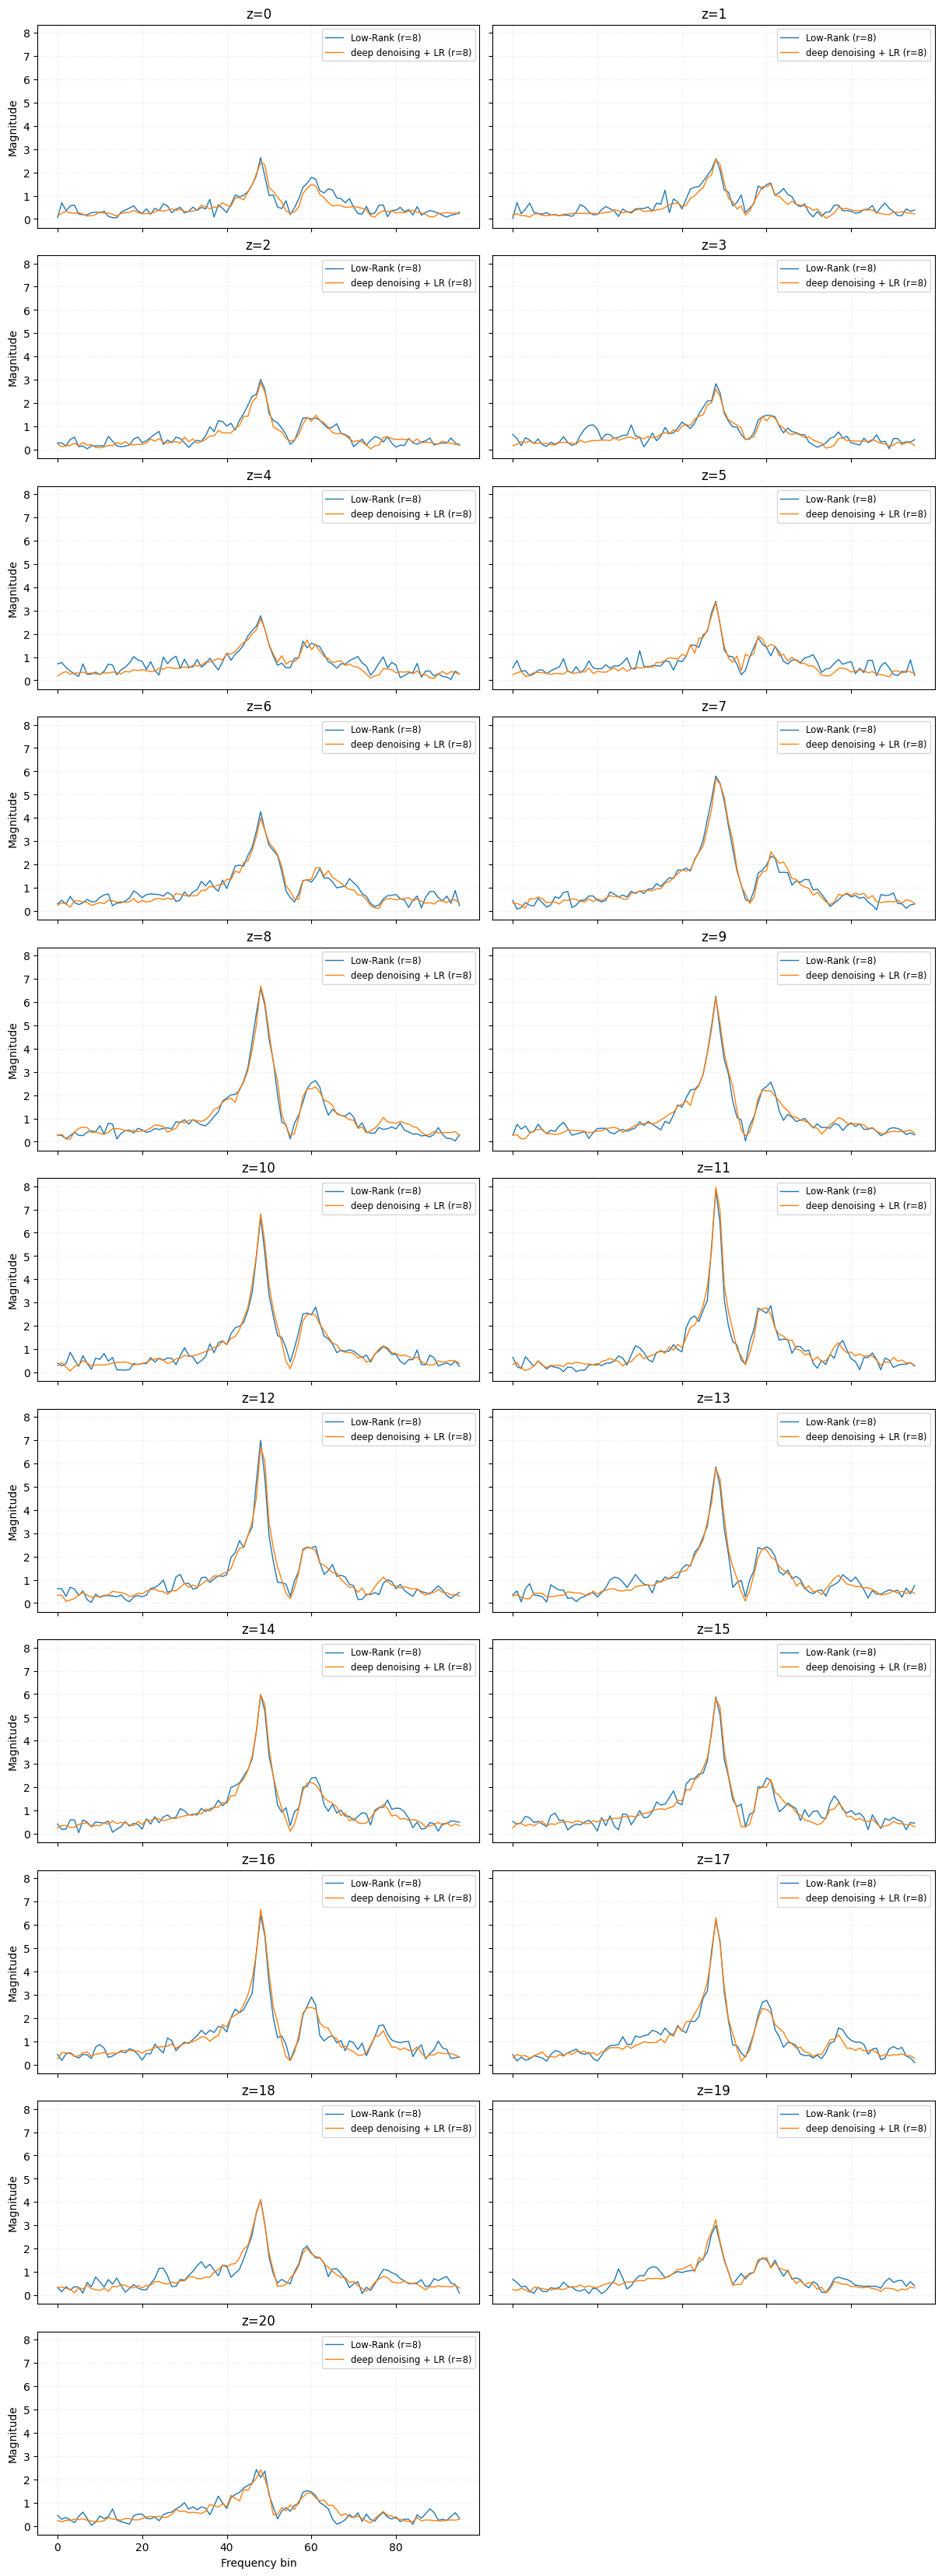

In [9]:
x,y,T = 10, 10, 0

# 2a) Deep-Denoising Spektrum
spec_deep = np.fft.fft(out_data, axis=3)
spec_deep = np.fft.fftshift(spec_deep, axes=3)

# 2b) Noisy Input Spektrum
spec_noisy = np.fft.fft(tgt_data, axis=3)
spec_noisy = np.fft.fftshift(spec_noisy, axes=3)

# 2c) Low-Rank Baseline Spektrum
spec_lr = np.fft.fft(baseline_data, axis=3)
spec_lr = np.fft.fftshift(spec_lr, axes=3)

# ── 21 Spektren für z=0…20 in einem 5×5-Grid plotten ─────────────────────────

# ── 21 Spektren (Noisy vs. Low-Rank vs. Noise2Void) in 2 Spalten ────────────

# ── 21 Spektren in 2 Spalten mit eigener Legende pro Plot und größerer Figure ──

import numpy as np
import matplotlib.pyplot as plt

# Parameter
x, y, T = 10, 10, 7
Z       = spec_noisy.shape[2]   # Anzahl der z-Slices (hier 21)
F       = spec_noisy.shape[3]   # Anzahl der Frequenz-Bins
freqs   = np.arange(F)
rank    = 8                     # Rang für Low-Rank

# Grid-Layout: 2 Spalten, genug Zeilen
n_cols  = 2
n_rows  = int(np.ceil(Z / n_cols))

# Figure größer machen: Breite × Höhe in Zoll
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(12, n_rows * 3),
    sharex=True, sharey=True,
    constrained_layout=True
)

for z in range(Z):
    i, j = divmod(z, n_cols)
    ax = axes[i, j]

    # Magnituden extrahieren
    mag_noisy = np.abs(spec_noisy[x, y, z, :, T])
    mag_lr    = np.abs(spec_lr   [x, y, z, :, T])
    mag_deep  = np.abs(spec_deep [x, y, z, :, T])

    # Plots
    ax.plot(freqs, mag_lr,    '-', label=f'Low-Rank (r={rank_post})', linewidth=1)
    ax.plot(freqs, mag_deep,  '-',  label=f'deep denoising + LR (r={rank_post})', linewidth=1)

    ax.set_title(f"z={z}")
    ax.grid(True, linestyle=':', alpha=0.3)

    # Legende für jeden Subplot
    ax.legend(fontsize='small', loc='upper right')

    # Achsenbeschriftungen nur außen
    if i == n_rows - 1:
        ax.set_xlabel("Frequency bin")
    if j == 0:
        ax.set_ylabel("Magnitude")

# Leere Subplots ausblenden
for idx in range(Z, n_rows * n_cols):
    i, j = divmod(idx, n_cols)
    axes[i, j].axis('off')

plt.savefig("spectra.png", dpi=300)
plt.show()

# Compare spectral peaks

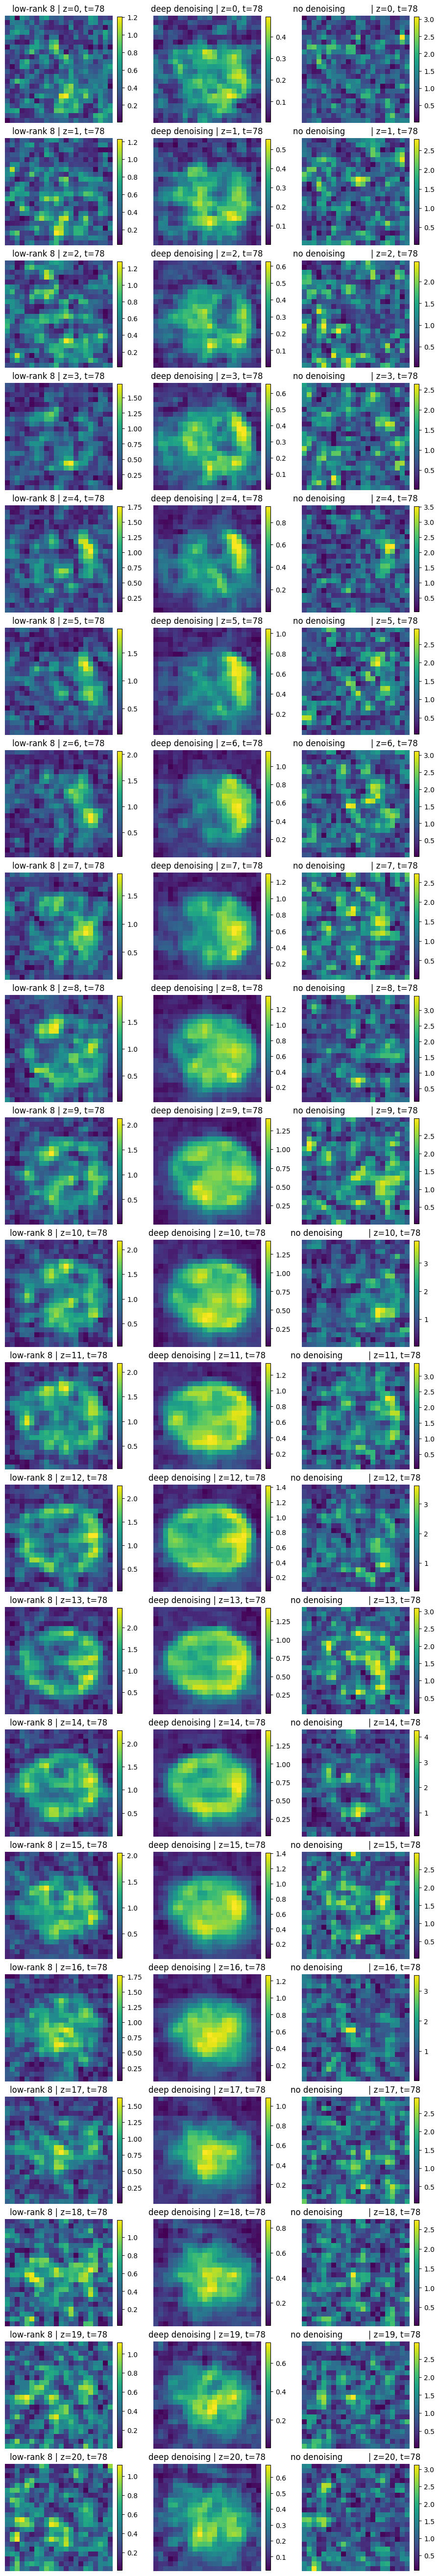

In [10]:
# ── Vergleich aller Z-Slices: Low-Rank | Deep Denoising | Input ─────────────

import numpy as np
import matplotlib.pyplot as plt

# 1) t- und T-Indizes einstellen
t, T = 78, 7

# 2) Anzahl der Z-Slices automatisch ermitteln
n_slices = out_data.shape[2]

# 3) Subplots erzeugen: n_slices Zeilen × 3 Spalten
fig, axes = plt.subplots(
    n_slices, 3,
    figsize=(9, n_slices * 2.5),
    constrained_layout=True
)

for i, z in enumerate(range(n_slices)):
    # 4) 2D-Slices extrahieren
    slice_lr   = np.abs(baseline_data_ft[:, :, z, t, T])  # Low-Rank
    slice_deep = np.abs(out_data_ft[:, :, z, t, T])       # Deep Denoised
    slice_in   = np.abs(tgt_data_ft[:, :, z, t, T])       # Original Input

    # 5a) Low-Rank
    im0 = axes[i, 0].imshow(slice_lr,   cmap='viridis')
    axes[i, 0].set_title(f"low-rank {rank_post} | z={z}, t={t}")
    axes[i, 0].axis('off')
    plt.colorbar(im0, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # 5b) Deep Denoising
    im1 = axes[i, 1].imshow(slice_deep, cmap='viridis')
    axes[i, 1].set_title(f"deep denoising | z={z}, t={t}")
    axes[i, 1].axis('off')
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # 5c) Input
    im2 = axes[i, 2].imshow(slice_in,   cmap='viridis')
    axes[i, 2].set_title(f"no denoising          | z={z}, t={t}")
    axes[i, 2].axis('off')
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.savefig("denoising_p2n.png", dpi=300)
plt.show()

# Compare average spectra
Here I compare the average spectrum over time (which is a high SNR estimate) for gey matter which matter and all matter

In [11]:
avg_out = np.mean(out_data_ft, axis=(0, 1, 2))

avg_lr = np.mean(baseline_data_ft, axis=(0, 1, 2))

avg_tgt = np.mean(tgt_data_ft, axis=(0, 1, 2))

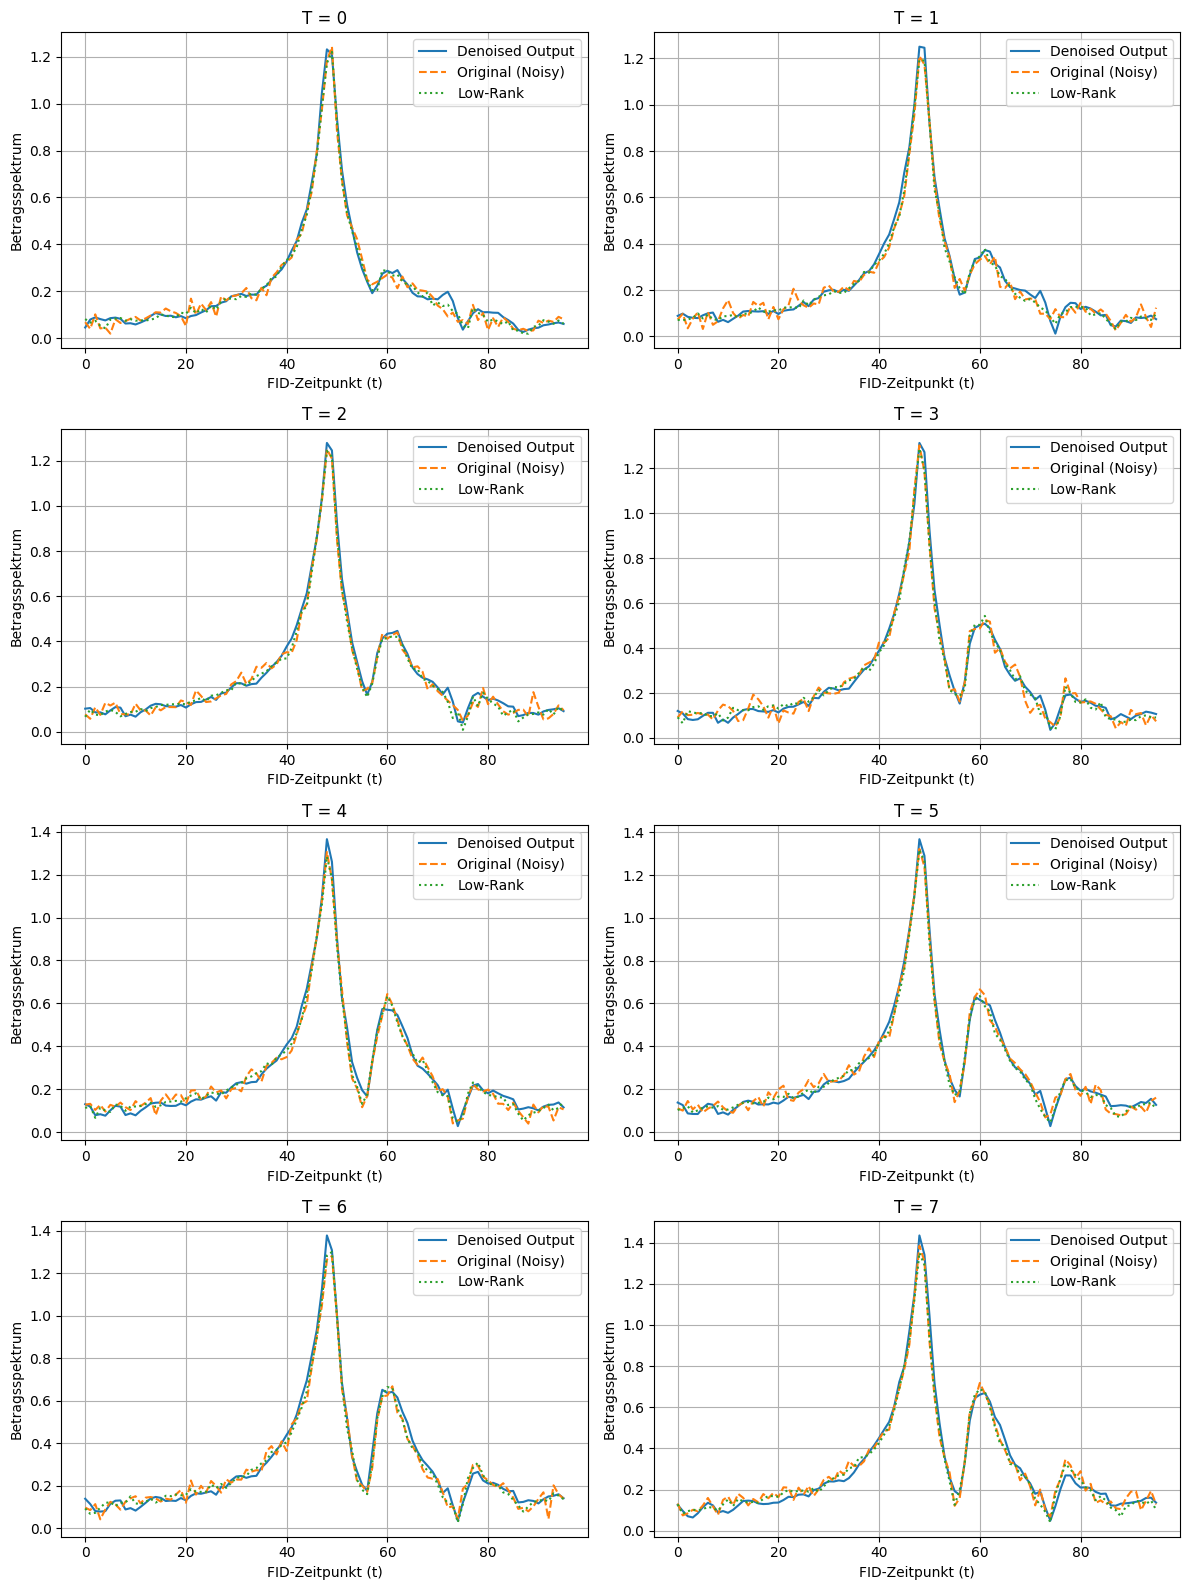

In [12]:
import matplotlib.pyplot as plt

# Subplot-Grid: 4 Zeilen × 2 Spalten für T = 0 bis 7
num_rows, num_cols = 4, 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 16))

for idx, T in enumerate(range(8)):
    i = idx // num_cols
    j = idx % num_cols
    ax = axes[i, j]
    
    # Spektren extrahieren
    Line   = np.abs(avg_out)[:, T]
    Line_2 = np.abs(avg_tgt)[:, T]
    Line_3 = np.abs(avg_lr)[:, T]
    
    ax.plot(Line,   label="Denoised Output")
    ax.plot(Line_2, linestyle="--", label="Original (Noisy)")
    ax.plot(Line_3, linestyle=":",  label="Low-Rank")
    
    ax.set_xlabel("FID-Zeitpunkt (t)")
    ax.set_ylabel("Betragsspektrum")
    ax.set_title(f"T = {T}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# Check spatial noise correlation

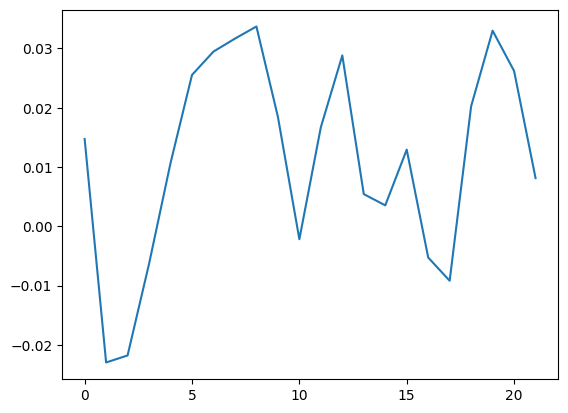

In [19]:
y, z, t, T = -1, -1, -1, -1

Line = baseline_data[:,y,z,t,T]

plt.plot(np.imag(Line))



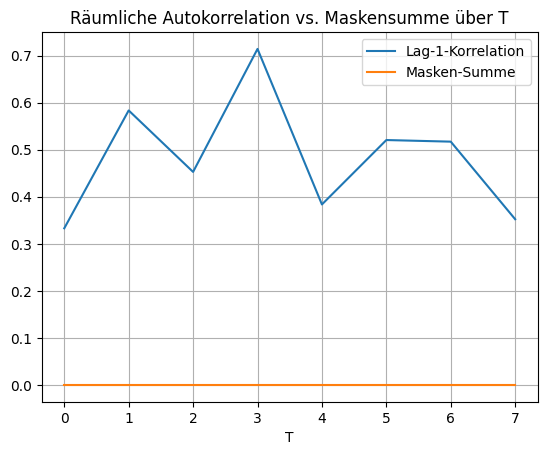

In [21]:

import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

mask = np.load('../datasets/P08/mask.npy')

# Dummy: ersetze durch reale Daten, z. B. noise = tgt_data - out_data
# Wir nehmen eine Linie entlang X bei festen Y,Z,t,T
y, z, t, T = -1, -1, -1, 2
line = np.imag(tgt_data[:, y, z, t, T])  # oder np.imag()

# Plot zur Übersicht
# plt.plot(line)
# plt.title("Signal entlang X")
# plt.show()

# Berechnung des Lag-1-Korrelationskoeffizienten
def lag1_corr(x):
    x = x - np.mean(x)
    return np.corrcoef(x[:-1], x[1:])[0, 1]

mask_sums = []
rho_values = []

for T in range(8):
    line = np.imag(tgt_data[:, y, z, t, T])
    mask_sum = np.sum(mask[:, y, z])
    rho = lag1_corr(line)

    mask_sums.append(mask_sum)
    rho_values.append(rho)

# Plot
plt.plot(rho_values, label="Lag-1-Korrelation")
plt.plot(mask_sums, label="Masken-Summe")
plt.xlabel("T")
plt.legend()
plt.title("Räumliche Autokorrelation vs. Maskensumme über T")
plt.grid(True)
plt.show()

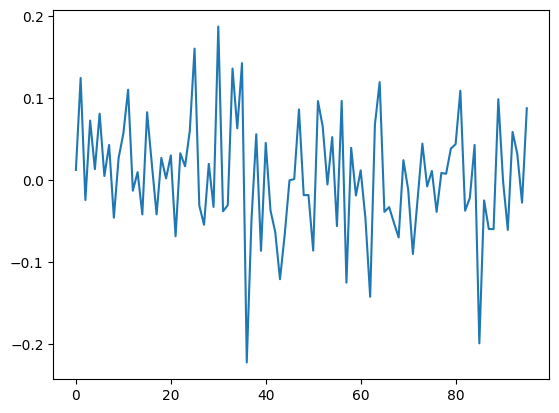

In [24]:
x, y, z, t, T = -1, -1, -1, -1, -1

Line = tgt_data[x,y,z,:,T]

plt.plot(np.imag(Line))



In [29]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

mask = np.load('../datasets/P08/mask.npy')

# Dummy: ersetze durch reale Daten, z. B. noise = tgt_data - out_data
# Wir nehmen eine Linie entlang X bei festen Y,Z,t,T
x,y, z, f, T = -2, -1, -1, -3
line = np.imag(tgt_data[x, y, z, f, :])  # oder np.imag()

# Plot zur Übersicht
# plt.plot(line)
# plt.title("Signal entlang X")
# plt.show()

# Berechnung des Lag-1-Korrelationskoeffizienten
def lag1_corr(x):
    x = x - np.mean(x)
    return np.corrcoef(x[:-1], x[1:])[0, 1]

mask_sums = []
rho_values = []

for T in range(8):
    line = np.imag(baseline_data[x, y, z, f, :])
    mask_sum = np.sum(mask[x, y, z])
    rho = lag1_corr(line)

    mask_sums.append(mask_sum)
    rho_values.append(rho)

# Plot
plt.plot(rho_values, label="Lag-1-Korrelation")
plt.plot(mask_sums, label="Masken-Summe")
plt.xlabel("T")
plt.legend()
plt.title("Räumliche Autokorrelation vs. Maskensumme über T")
plt.grid(True)
plt.show()

ValueError: not enough values to unpack (expected 5, got 4)

In [17]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

mask = np.load('../datasets/P08/mask.npy')

# Dummy: ersetze durch reale Daten, z. B. noise = tgt_data - out_data
# Wir nehmen eine Linie entlang X bei festen Y,Z,t,T
x, y, z, t, T = -1,-1, -1, -1
line = np.imag(tgt_data[:, y, z, :, T])  # oder np.imag()

# Plot zur Übersicht
# plt.plot(line)
# plt.title("Signal entlang X")
# plt.show()

# Berechnung des Lag-1-Korrelationskoeffizienten
def lag1_corr(x):
    x = x - np.mean(x)
    return np.corrcoef(x[:-1], x[1:])[0, 1]

# Ergebnis
for T in range(0,8):
    line = np.imag(tgt_data[:, y, z, t, T])  # oder np.imag()
    mask_sum = np.sum(mask[:,y,z])
    rho = lag1_corr(line)
    print('sum of head mask:')
    print(mask_sum)
    print(f"Lag-1-Korrelationskoeffizient entlang X: {rho:.3f}")

ValueError: not enough values to unpack (expected 5, got 4)